# TABLA COMPARATIVA RESULTADOS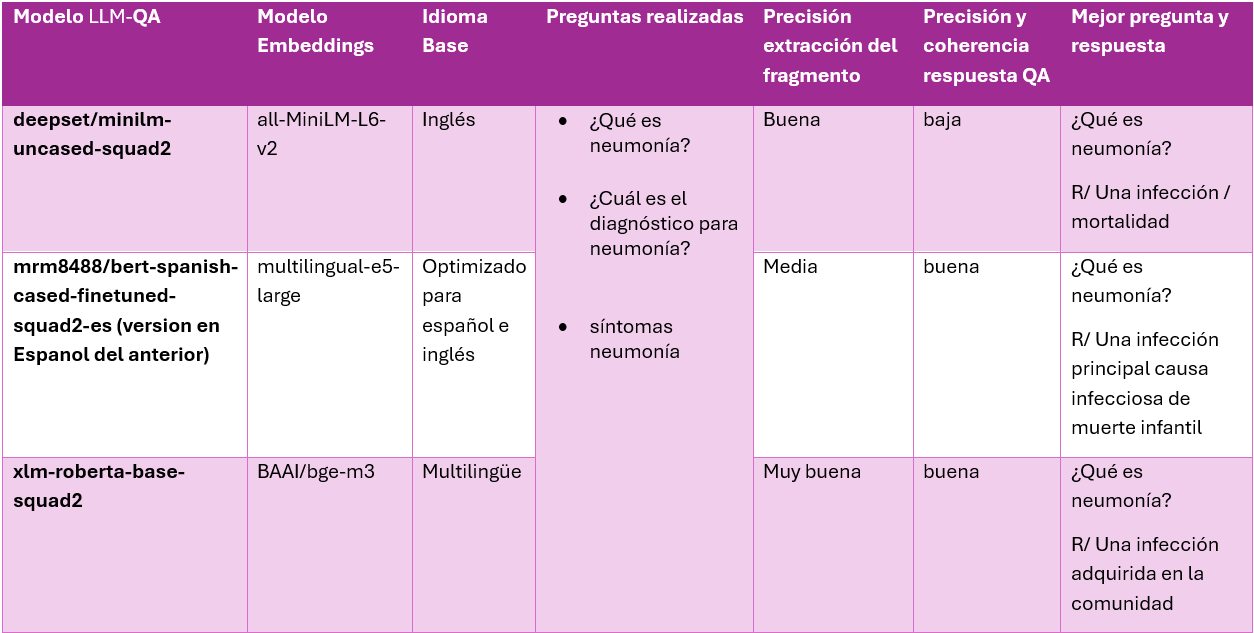

DESCARGAS

In [1]:
!pip install -q langchain
!pip install -q torch
!pip install -q transformers
!pip install -q sentence-transformers
!pip install -q datasets
!pip install -q faiss-cpu
!pip install -q pypdf
!pip install tqdm
!pip install -U langchain-community
!pip install langchain langchain-community pypdf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
from langchain.document_loaders import HuggingFaceDatasetLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
from transformers import AutoTokenizer, pipeline
from langchain import HuggingFacePipeline
from langchain.chains import RetrievalQA
import torch
from langchain import PromptTemplate, LLMChain
from tqdm.notebook import tqdm
from langchain.document_loaders import PyPDFLoader


from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline,
    AutoModelForCausalLM
    )


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")#verificar compatibilidad con GPU
print(device) # Disponible "cuda"/NO disponible "cpu"

def print_lines(text, max_ch = 50): #verificar que cada línea no exceda la longitud máxima de caracteres especificada
  current_line = ""
  words = text.split()
  i = 0
  while i < len(words):
    if len(current_line) > 50:
      print(current_line)
      current_line = ""
    else:
      current_line += f"{words[i]} "
      i+=1
  if current_line:
    print(current_line)

cuda


CARGA DE INFORMACIÓN

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
list_pdf = "/content/drive/MyDrive/Colab Notebooks/AUTOMATIZACIÓN 2/NEUMO DOCS"

In [6]:
import os
path_docs = "/content/drive/MyDrive/Colab Notebooks/AUTOMATIZACIÓN 2/NEUMO DOCS"

os.listdir(path_docs)

['Dialnet-GuiaDePracticaClinicaParaElManejoDeLaNeumoniaAdqui-8801418.pdf',
 '1-s2.0-S0300289620300405-main.pdf',
 'Pediatria-Integral-XX-1_WEB.pdf',
 'Protocolos_del_GVR_P_GVR_8_El_Pediatra_d.pdf',
 'Epidemiología de la neumonía adquirida en comunidad.pdf']

In [7]:
# Document Transformers
from tqdm.notebook import tqdm #visualizar barras de proceso
from langchain.document_loaders import PyPDFLoader #cargar y leer archivos PDF.

chunk_size = 1000 # longitud máxima de cada fragmento de texto en caracteres.
chunk_overlap = 200 # caracteres que se superponen entre fragmentos

In [8]:
# Crear divisor de texto
text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)

# Lista donde se guardan todos los fragmentos
all_docs = []

# Recorre los archivos PDF y los carga en fragmentos
for name in tqdm(os.listdir(path_docs)):
    if name.endswith(".pdf"):
        path_tmp = os.path.join(path_docs, name)
        loader = PyPDFLoader(path_tmp)
        text = loader.load()  # carga el texto del PDF
        chunks_of_text = text_splitter.split_documents(text)
        all_docs.extend(chunks_of_text)

print(f"Se cargaron {len(all_docs)} fragmentos en total ")

  0%|          | 0/5 [00:00<?, ?it/s]

Se cargaron 938 fragmentos en total 


In [9]:
print(all_docs)

[Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-02-14T14:53:22-05:00', 'moddate': '2023-02-14T14:53:24-05:00', 'trapped': '/False', 'source': '/content/drive/MyDrive/Colab Notebooks/AUTOMATIZACIÓN 2/NEUMO DOCS/Dialnet-GuiaDePracticaClinicaParaElManejoDeLaNeumoniaAdqui-8801418.pdf', 'total_pages': 37, 'page': 0, 'page_label': '1'}, page_content='1/37\nRev. Fac. Med.  | \nClinical Practice Guideline for the management of \ncommunity-acquired pneumonia\nGuía de práctica clínica para el manejo de la neumonía adquirida en la comunidad\nJorge Alberto Cortés1,2  Sonia Isabel Cuervo-Maldonado1  Laura Cristina Nocua-Báez1  Martha Carolina \nValderrama1  Edgar Alberto Sánchez1,3  Alfredo Saavedra1,3  July Vianneth T orres3  Diana Paola Forero3  \nCarlos Arturo Álvarez-Moreno1  Aura Lucía Leal4,5,6  Jairo Enrique Pérez7  Iván Arturo Rodríguez8  Fredy \nOrlando Guevara9,10  Carlos Humberto Saavedra1  Erika Paola Vergara1,2

In [10]:
from pprint import pprint #pretty-printing
chunk = all_docs[450]

print_lines(chunk.page_content)

pprint(chunk.metadata)#imprimir un fragmento

invierno. Puede producir bronquio - litis con tos pertusioide(4). 
Epidemiología El VRS es la causa más frecuente de bronquiolitis, 
y presenta un patrón esta- cional. 0% 10% 20% 30% 40% 
50% 60% VRS Rhinovirus Parainfluenza Metapneumovirus 
Influenza Adenovirus Coronavirus Bocavirus Figura 1. 
Etiología de Bronquiolitis aguda (septiembre 2005-agosto 
2008). Calvo C. et al. Hospital Severo Ochoa. Acta 
Pædiatrica. 2010. Se documentó un virus en el 86% de 
los pacientes. Hubo coinfección por más de un virus 
en el 29%. Figura 2. Porcentaje de episodios mensuales 
de Bronquiolitis asociados a diferentes virus (septiembre 
2005-agosto 2008). Calvo C et al. Hospital Severo Ochoa. 
Acta Pædiatrica. 2010. 
{'creationdate': '2016-02-19T14:48:50+01:00',
 'creator': 'Adobe InDesign CS6 (Windows)',
 'moddate': '2017-10-11T22:53:32+02:00',
 'page': 30,
 'page_label': '29',
 'producer': 'Adobe PDF Library 10.0.1',
 'source': '/content/drive/MyDrive/Colab Notebooks/AUTOMATIZACIÓN 2/NEUMO '
        

EMBEDDINGS 1. Inglés (all-MiniLM-L6-v2)


In [140]:
# crear embeddings: representar textos como vectores de números en un espacio de alta dimensión
def get_embeddings_model(model_path=None):
  modelPath = "sentence-transformers/all-MiniLM-l6-v2" #modelo de embeddings
  device = torch.device(
      "cuda" if torch.cuda.is_available() else "cpu"
      )
  #device = "cpu"
  if model_path:
    modelPath = model_path
  model_kwargs = {'device':device} #device sobre el que corre el modelo
  encode_kwargs = {'normalize_embeddings': False} #los espacios embebidos no se normalizan automaticamente
  #Útil para mantener la magnitud(importancia) de los vectores

  embeddings = HuggingFaceEmbeddings(
      model_name=modelPath,     # Provide the pre-trained model's path
      model_kwargs=model_kwargs, # Pass the model configuration options
      encode_kwargs=encode_kwargs # Pass the encoding options
  )
  print(f"device: {device}")
  return embeddings


In [141]:
embeddings = get_embeddings_model()

device: cuda


In [142]:
db = FAISS.from_documents(all_docs, embeddings) # toma los documentos y sus representaciones en embeddings, y construye un índice que permite realizar búsquedas de manera eficiente.

In [143]:
question = "¿Qué es Neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

REVISTA DE LA FACULTAD DE MEDICINA GPC para el manejo 
de NAC 2/37 Rev. Fac. Med. | https://doi.org/10.15446/revfacmed.v70n2.93814 
Introduction La neumonía es una infección que puede 
afectar uno o ambos pulmones y cuya sintoma- tología 
puede variar de leve a grave, incluyendo tos (con o 
sin mocos), fiebre, escalofríos y dificultad para respirar. 
El grado de severidad de la neumonía depende de factores 
como la edad, el estado de salud general y la causa 
de la infección.1 Si bien la neumonía puede afectar 
a personas de todas las edades, los grupos etarios 
con un mayor riesgo de desarrollar neu- monía y de 
que esta sea grave son los niños de 2 años o menores 
y los mayores de 65 años.1 De hecho, se ha reportado 
que, en comparación con otros grupos etarios, la tasa 
global de mortalidad por neumonía más alta ocurre en 
las personas de 70 o más años, con 261 muertes por 
neumonía por cada 100 000 personas en 2017 para este 
grupo etario.2 


In [148]:
question = "síntomas neumonía"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

NeumoNía y NeumoNía recurreNte PEDIATRÍA INTEGRAL 44 
Puntos clave: - La temperatura >39ºC, saturacio - nes 
<94%, taquicardia y tiempo llenado capilar > 2 s, se 
asocian con más probabilidad a infecciones severas. 
Tratamiento Ante la sospecha clínica de NAC de origen 
bacteriano, se debe iniciar trata- miento antibiótico. 
Si la sintomatología es compatible con neumonía típica, 
el ATB de elección es la amoxicilina oral a dosis altas 
y si se sospecha neumonía atípica, se recomienda usar 
un macrólido. Indicación de tratamiento ATB En los 
niños menores de 2 años, la etiología más frecuente 
de infec - ción respiratoria de vías inferiores son 
los virus. Por ello, ante un cua - dro clínico con 
sintomatología leve, especialmente en niños pequeños 
correctamente vacunados para H. influenzae tipo b y 
S. pneumoniae, se recomienda únicamente tratamiento 
de soporte, aunque deben ser revalo - rados en 24-48 
horas si la sintomato - logía persiste. En el resto 
de los casos, ante la 


In [151]:
question = "¿Cuál es el diagnóstico para neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

con NR para llegar al diagnóstico son muy numerosas 
y, en alguno de los casos, no exentas de efectos secunda 
- rios. Por ello, se recomienda iniciar el proceso 
diagnóstico con una correcta anamnesis y exploración 
física que orienten hacia la posible etiología. Anamnesis 
Inicialmente, hay que obtener la máxima información 
sobre los dife - rentes episodios de neumonía: edad, 
estacionalidad, sintomatología acom - pañante, localización, 
exploraciones complementarias realizadas, trata - miento 
administrado, duración del episodio y si ha habido 
resolución completa del mismo. Los antecedentes familiares 
son especialmente relevantes en el caso de patologías 
con componente hereditario con la fibrosis quística, 
el asma o cierto tipo de inmunodeficiencias. También, 
es importante pregun - tar por lo acontecido en el 
periodo neonatal, si hay antecedentes de atra - gantamiento, 
si existen problemas de deglución, sintomatología respiratoria 
entre los episodios (tos, expectoración, 


In [117]:
import re
def get_context(db, question, top_k = 2): #devuelve los 2 mejores resultado de la busqueda en la base de datos
  searchDocs = db.similarity_search(question, k= top_k)
  return re.sub(r"\t+", " ", "\n".join([x.page_content for x in searchDocs])) #remplazar tabulación

In [152]:
get_context(db, question)

'con NR para llegar al diagnóstico son \nmuy numerosas y, en alguno de los \ncasos, no exentas de efectos secunda -\nrios. Por ello, se recomienda iniciar el \nproceso diagnóstico con una correcta \nanamnesis y exploración física que \norienten hacia la posible etiología.\nAnamnesis\nInicialmente, hay que obtener la \nmáxima información sobre los dife -\nrentes episodios de neumonía: edad, \nestacionalidad, sintomatología acom\n-\npañante, localización, exploraciones \ncomplementarias realizadas, trata -\nmiento administrado, duración del \nepisodio y si ha habido resolución \ncompleta del mismo.\nLos antecedentes familiares son \nespecialmente relevantes en el caso de \npatologías con componente hereditario \ncon la fibrosis quística, el asma o cierto \ntipo de inmunodeficiencias.\nTambién, es importante pregun\n-\ntar por lo acontecido en el periodo \nneonatal, si hay antecedentes de atra\n-\ngantamiento, si existen problemas de \ndeglución, sintomatología respiratoria \nentre los ep

modelo de pregunta-respuesta (LLM) 1. Inglés (deepset/minilm-uncased-squad2)

In [145]:
from transformers import AutoModelForQuestionAnswering
from transformers import TFAutoModelForQuestionAnswering
models_hf = ["deepset/minilm-uncased-squad2"] #modelo optimizado de question answering
model_ckpt = models_hf[0] #la posición 0 es la referencia del modelo

In [146]:
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)#carga del modelo pre entrenado
tokenizer = AutoTokenizer.from_pretrained(model_ckpt) #a formato adecuado para que el modelo lo interprete
#tokenizador es la primera etapa de preparación del texto para un modelo

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


CONTEXTO: El tokenizador rompe el texto en piezas y las convierte en números que el modelo puede "leer", mientras que los embeddings le dan a esas piezas numéricas un "significado" capturado en un espacio vectorial, permitiendo al modelo entender las relaciones entre ellas. El tokenizador es el paso de pre-procesamiento, y el embedding es una representación interna utilizada por el modelo para entender el lenguaje.

In [147]:
question = "¿Qué es neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.5987735806120327,
  'start': 159,
  'end': 172,
  'answer': 'una infección'},
 {'score': 0.3558197662932798,
  'start': 1490,
  'end': 1521,
  'answer': 'Mortalidad\nDe los 406 pacientes'},
 {'score': 0.23328611077158712,
  'start': 786,
  'end': 796,
  'answer': 'mortalidad'}]

In [150]:
question = "síntomas neumonía"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.024652102147229016, 'start': 0, 'end': 8, 'answer': 'NeumoNía'},
 {'score': 0.021444980055093765,
  'start': 0,
  'end': 19,
  'answer': 'NeumoNía y NeumoNía'},
 {'score': 0.01026869541965425,
  'start': 1100,
  'end': 1118,
  'answer': 'neumonía adquirida'}]

In [153]:
question = "¿Cuál es el diagnóstico para neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 1.0229686917737126,
  'start': 1741,
  'end': 1754,
  'answer': 'poco probable'},
 {'score': 0.6609636545181274,
  'start': 1746,
  'end': 1754,
  'answer': 'probable'},
 {'score': 0.08926829323172569,
  'start': 1738,
  'end': 1754,
  'answer': 'es poco probable'}]


Embeddings 2. Optimizado para español e inglés(intfloat/multilingual-e5-large)

In [154]:
embeddings= get_embeddings_model(model_path="intfloat/multilingual-e5-large")


device: cuda


In [124]:
db = FAISS.from_documents(all_docs, embeddings) # toma los documentos y sus representaciones en embeddings, y construye un índice que permite realizar búsquedas de manera eficiente.

In [125]:
question = "¿Qué es Neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

REVISTA DE LA FACULTAD DE MEDICINA GPC para el manejo 
de NAC 2/37 Rev. Fac. Med. | https://doi.org/10.15446/revfacmed.v70n2.93814 
Introduction La neumonía es una infección que puede 
afectar uno o ambos pulmones y cuya sintoma- tología 
puede variar de leve a grave, incluyendo tos (con o 
sin mocos), fiebre, escalofríos y dificultad para respirar. 
El grado de severidad de la neumonía depende de factores 
como la edad, el estado de salud general y la causa 
de la infección.1 Si bien la neumonía puede afectar 
a personas de todas las edades, los grupos etarios 
con un mayor riesgo de desarrollar neu- monía y de 
que esta sea grave son los niños de 2 años o menores 
y los mayores de 65 años.1 De hecho, se ha reportado 
que, en comparación con otros grupos etarios, la tasa 
global de mortalidad por neumonía más alta ocurre en 
las personas de 70 o más años, con 261 muertes por 
neumonía por cada 100 000 personas en 2017 para este 
grupo etario.2 


In [131]:
question = "síntomas neumonía"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

REVISTA DE LA FACULTAD DE MEDICINA GPC para el manejo 
de NAC 2/37 Rev. Fac. Med. | https://doi.org/10.15446/revfacmed.v70n2.93814 
Introduction La neumonía es una infección que puede 
afectar uno o ambos pulmones y cuya sintoma- tología 
puede variar de leve a grave, incluyendo tos (con o 
sin mocos), fiebre, escalofríos y dificultad para respirar. 
El grado de severidad de la neumonía depende de factores 
como la edad, el estado de salud general y la causa 
de la infección.1 Si bien la neumonía puede afectar 
a personas de todas las edades, los grupos etarios 
con un mayor riesgo de desarrollar neu- monía y de 
que esta sea grave son los niños de 2 años o menores 
y los mayores de 65 años.1 De hecho, se ha reportado 
que, en comparación con otros grupos etarios, la tasa 
global de mortalidad por neumonía más alta ocurre en 
las personas de 70 o más años, con 261 muertes por 
neumonía por cada 100 000 personas en 2017 para este 
grupo etario.2 


In [134]:
question = "¿Cuál es el diagnóstico para neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

fiebre, la tos y la afectación del estado general, 
tienen una significación varia - ble. En la auscultación, 
se objetivan tanto sibilancias como crepitantes de 
forma difusa. El VRS es el principal virus cau - sante 
de neumonías. Otros virus cau- santes son: Influenza 
A y B, Parain - fluenza 1, 2 y 3, Adenovirus, Rhino 
- virus, Metapneumovirus, Bocavirus, Coronavirus, Enterovirus 
y Varicela, entre otros. Diagnóstico radiológico La 
radiografía de tórax se utiliza a menudo para diagnosticar 
la NAC, pero muchos estudios han demostrado que no 
mejora los resultados clínicos ni cambia significativamente 
el tratamiento. La etiología de la neumonía puede sospecharse 
por los hallazgos radio - lógicos, aunque diversos 
estudios han demostrado que no siempre hay buena correlación: 
• El derrame pleural en la radiografía de tórax es 
el predictor más impor- tante de neumonía bacteriana. 
• El infiltrado alveolar es más suges- tivo de bacterias 
que de infección 


In [43]:
import re
def get_context(db, question, top_k = 2): #devuelve los 2 mejores resultado de la busqueda en la base de datos
  searchDocs = db.similarity_search(question, k= top_k)
  return re.sub(r"\t+", " ", "\n".join([x.page_content for x in searchDocs])) #remplazar tabulación

In [135]:
get_context(db, question)

'fiebre, la tos y la afectación del estado \ngeneral, tienen una significación varia\n-\nble. En la auscultación, se objetivan \ntanto sibilancias como crepitantes de \nforma difusa.\nEl VRS es el principal virus cau -\nsante de neumonías. Otros virus cau-\nsantes son: Influenza A y B, Parain -\nfluenza 1, 2 y 3, Adenovirus, Rhino -\nvirus, Metapneumovirus, Bocavirus, \nCoronavirus, Enterovirus y Varicela, \nentre otros.\nDiagnóstico radiológico\nLa radiografía de tórax se utiliza a \nmenudo para diagnosticar la NAC, pero \nmuchos estudios han demostrado que no \nmejora los resultados clínicos ni cambia \nsignificativamente el tratamiento.\nLa etiología de la neumonía puede \nsospecharse por los hallazgos radio -\nlógicos, aunque diversos estudios han \ndemostrado que no siempre hay buena \ncorrelación:\n•  El  derrame pleural en la radiografía \nde tórax es el predictor más impor-\ntante de neumonía bacteriana.\n•  El  infiltrado alveolar es más suges-\ntivo de bacterias que de infecc

modelo de QA (LLM) 2. es el equivalente español del modelo que ya usado anteriormente (mrm8488/bert-spanish-cased-finetuned-squad2-es)

In [126]:
models_hf = ["mrm8488/bert-spanish-cased-finetuned-squad2-es"]

In [127]:
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)#carga del modelo pre enttrenado
tokenizer = AutoTokenizer.from_pretrained(model_ckpt) #a formato adecuado para que el modelo lo interprete

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [130]:
question = "¿Qué es neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.6070467402605573,
  'start': 159,
  'end': 172,
  'answer': 'una infección'},
 {'score': 0.21592632529791445,
  'start': 163,
  'end': 172,
  'answer': 'infección'},
 {'score': 0.1752304881811142,
  'start': 1519,
  'end': 1565,
  'answer': 'principal causa \ninfecciosa de muerte infantil'}]

In [133]:
question = "síntomas neumonía"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.0496077798306942,
  'start': 236,
  'end': 264,
  'answer': 'puede variar de leve a grave'},
 {'score': 0.024275781586766243,
  'start': 242,
  'end': 264,
  'answer': 'variar de leve a grave'},
 {'score': 0.006938776466995478,
  'start': 249,
  'end': 264,
  'answer': 'de leve a grave'}]

In [136]:
question = "¿Cuál es el diagnóstico para neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.1645268441643566,
  'start': 1119,
  'end': 1129,
  'answer': 'requeridas'},
 {'score': 0.055890394491143525,
  'start': 1107,
  'end': 1129,
  'answer': 'diagnóstico requeridas'},
 {'score': 0.004067319445312023,
  'start': 1090,
  'end': 1129,
  'answer': 'laboratorio y de diagnóstico requeridas'}]

EMBEDDDING 3. Multilingüe y de última generación (muy buen rendimiento en español) (BAAI/bge-m3)

In [164]:
embeddings = get_embeddings_model(model_path="BAAI/bge-m3") #modelo embedding

db = FAISS.from_documents(all_docs, embeddings) # toma los documentos y sus representaciones en embeddings, y construye un índice que permite realizar búsquedas de manera eficiente.

device: cuda


In [156]:
question = "¿Qué es neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

REVISTA DE LA FACULTAD DE MEDICINA GPC para el manejo 
de NAC 2/37 Rev. Fac. Med. | https://doi.org/10.15446/revfacmed.v70n2.93814 
Introduction La neumonía es una infección que puede 
afectar uno o ambos pulmones y cuya sintoma- tología 
puede variar de leve a grave, incluyendo tos (con o 
sin mocos), fiebre, escalofríos y dificultad para respirar. 
El grado de severidad de la neumonía depende de factores 
como la edad, el estado de salud general y la causa 
de la infección.1 Si bien la neumonía puede afectar 
a personas de todas las edades, los grupos etarios 
con un mayor riesgo de desarrollar neu- monía y de 
que esta sea grave son los niños de 2 años o menores 
y los mayores de 65 años.1 De hecho, se ha reportado 
que, en comparación con otros grupos etarios, la tasa 
global de mortalidad por neumonía más alta ocurre en 
las personas de 70 o más años, con 261 muertes por 
neumonía por cada 100 000 personas en 2017 para este 
grupo etario.2 


In [168]:
question = "¿Cuál es el diagnóstico para neumonía?"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

con NR para llegar al diagnóstico son muy numerosas 
y, en alguno de los casos, no exentas de efectos secunda 
- rios. Por ello, se recomienda iniciar el proceso 
diagnóstico con una correcta anamnesis y exploración 
física que orienten hacia la posible etiología. Anamnesis 
Inicialmente, hay que obtener la máxima información 
sobre los dife - rentes episodios de neumonía: edad, 
estacionalidad, sintomatología acom - pañante, localización, 
exploraciones complementarias realizadas, trata - miento 
administrado, duración del episodio y si ha habido 
resolución completa del mismo. Los antecedentes familiares 
son especialmente relevantes en el caso de patologías 
con componente hereditario con la fibrosis quística, 
el asma o cierto tipo de inmunodeficiencias. También, 
es importante pregun - tar por lo acontecido en el 
periodo neonatal, si hay antecedentes de atra - gantamiento, 
si existen problemas de deglución, sintomatología respiratoria 
entre los episodios (tos, expectoración, 


In [171]:
question = "síntomas neumonía"
searchDocs = db.similarity_search(question) #realizar busqueda de similitud por distancia
print_lines(searchDocs[0].page_content) #searchDocs documentos que tienen contenido similar al embedding de la pregunta. Se imprime el contenido del primer documento (el más relevante)

síntomas (respiratorios y no respiratorios), pero los 
signos que sugieren neumonía son menos evidentes. Los 
síntomas varían en función de la edad, del microrganismo 
responsable y del estado nutricional e inmunitario 
del paciente. Los lactantes presentan mayor sintomatología 
general (irritabilidad, insomnio, somnolencia, vómitos, 
diarrea). La fiebre sin foco o el dolor abdominal y/o 
vómitos en un niño con fiebre de instauración brusca, 
también puede ser el inicio de una neumonía. El dolor 
costal lo refieren sobre todo los niños mayores y adolescentes. 


In [172]:
get_context(db, question)

'síntomas (respiratorios y no respiratorios), pero los signos que sugieren neumonía son menos \nevidentes.  \n Los síntomas varían en función de la edad, del microrganismo responsable y del estado \nnutricional e inmunitario del paciente. Los lactantes presentan mayor sintomatología general \n(irritabilidad, insomnio, somnolencia, vómitos, diarrea). La fiebre sin foco o el dolor abdominal y/o \nvómitos en un niño con fiebre de instauración brusca, también puede ser el inicio de una neumonía. \nEl dolor costal lo refieren sobre todo los niños mayores y adolescentes.\nsospecha de neumonía de la comu\n-\nnidad podemos encontrar los sig -\nnos y síntomas siguientes. Señale \nla respuesta MENOS probable:\na. Fiebre y decaimiento.\nb. Frecuencia respiratoria sobre \n40 rpm. Cada grado de fiebre \npuede subir 5-7 rpm la frecuen\n-\ncia respiratoria.\nc. Hipoventilación localizada.\nd. Soplo tubárico.\ne. Espiración alargada, roncus,  \nsibilancias dispersas.\nCaso clínico\n6. Lactante de 5 me

LLM 3. Modelo RoBERTa entrenado 100% en español bertin-project/bertin-roberta-base-spanish

In [158]:
models_hf = ["deepset/xlm-roberta-base-squad2"] #modelo optimizado de question answeringmodel_ckpt = models_hf[0] #la posición 0 es la referencia del modelo

In [159]:
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)#carga del modelo pre enttrenado
tokenizer = AutoTokenizer.from_pretrained(model_ckpt) #a formato adecuado para que el modelo lo interprete

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [160]:
question = "¿Qué es neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.6085927825479303,
  'start': 159,
  'end': 172,
  'answer': 'una infección'},
 {'score': 0.20833119750022888,
  'start': 1735,
  'end': 1760,
  'answer': 'adquirida en la comunidad'},
 {'score': 0.1934362443862483,
  'start': 163,
  'end': 172,
  'answer': 'infección'}]

In [173]:
question = "síntomas neumonía"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.029532360822486226,
  'start': 1341,
  'end': 1360,
  'answer': 'Neumonía bacteriana'},
 {'score': 0.02921988594607683,
  'start': 1350,
  'end': 1360,
  'answer': 'bacteriana'},
 {'score': 0.01680731400847435, 'start': 0, 'end': 8, 'answer': 'síntomas'}]

In [170]:
question = "¿Cuál es el diagnóstico para neumonía?"
context = get_context(db, question)
inputs = tokenizer(question, context, return_tensors="pt")#aplica tokenización
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)#definición de PipeLine para la tarea de pregunta-respuesta usando el modelo y el tokenizador cargados
pipe(question=question, context=context, topk=3) #aplicación del pipeline para la tarea

Device set to use cuda:0


[{'score': 0.021442305152959307,
  'start': 1057,
  'end': 1101,
  'answer': 'exploraciones comple -\nmentarias solicitaría'},
 {'score': 0.013739916721533518,
  'start': 1711,
  'end': 1716,
  'answer': 'viral'},
 {'score': 0.012972142547369003,
  'start': 155,
  'end': 162,
  'answer': 'proceso'}]